<a href="https://colab.research.google.com/github/aglae26/challenge2-data-science/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [28]:
import pandas as pd
import requests

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)

In [6]:
df = pd.json_normalize(df.to_dict(orient="records"))


#🔧 Transformación

In [8]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [7]:
print("Número de duplicados:", df.duplicated().sum())

Número de duplicados: 0


In [9]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [10]:
df = df.dropna()

In [15]:
df.columns = df.columns.str.replace('.', '_')

In [16]:
df['account_Charges_Monthly'] = pd.to_numeric(df['account_Charges_Monthly'], errors='coerce')

df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [17]:
print(df['Churn'].unique())

['No' 'Yes' '']


In [19]:
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

df[['account_Charges_Monthly','Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [20]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


#📊 Carga y análisis

Análisis descriptivo general

In [21]:
df.describe()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,72.000000,118.750000,8684.800000,3.958333


Análisis de variables categóricas

In [22]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


Estadísticas de cargos mensuales

In [23]:
df['account_Charges_Monthly'].describe()

,account_Charges_Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


Estadísticas de cargos diarios

In [24]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


Promedio de cargos

In [25]:
df.groupby('Churn')['account_Charges_Monthly'].mean()

,account_Charges_Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


Tiempo promedio de permanencia

In [26]:
df['customer_tenure'].describe()

,customer_tenure
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


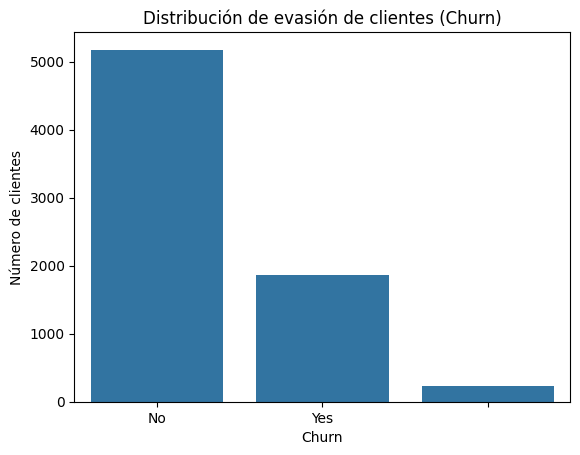

In [29]:
sns.countplot(x='Churn', data=df)

plt.title("Distribución de evasión de clientes (Churn)")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()

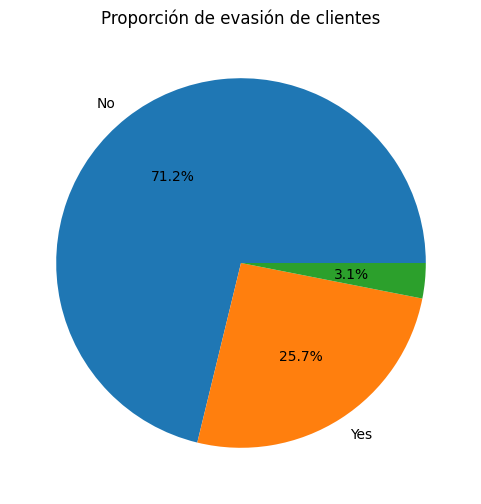

In [30]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')

plt.title("Proporción de evasión de clientes")
plt.show()

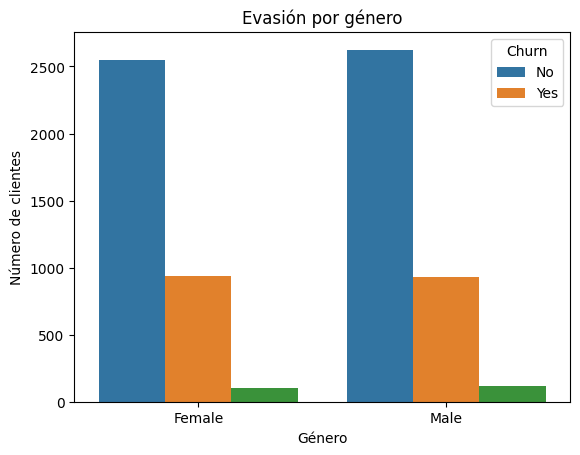

In [31]:
sns.countplot(x='customer_gender', hue='Churn', data=df)

plt.title("Evasión por género")
plt.xlabel("Género")
plt.ylabel("Número de clientes")

plt.show()

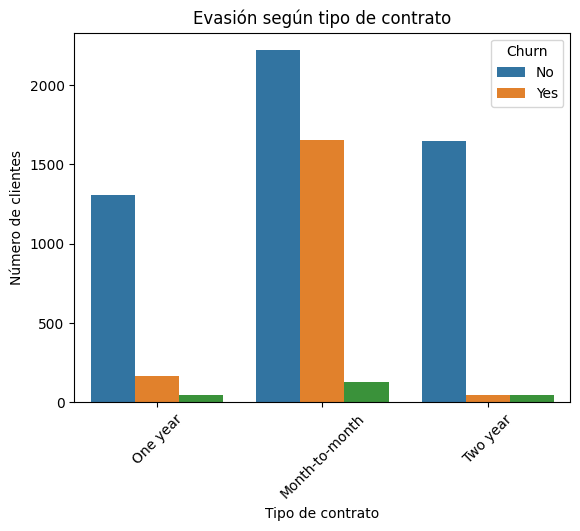

In [32]:
sns.countplot(x='account_Contract', hue='Churn', data=df)

plt.title("Evasión según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

plt.xticks(rotation=45)
plt.show()

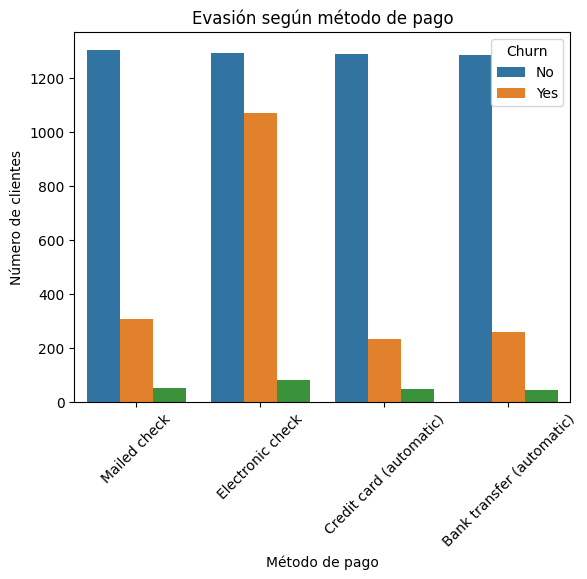

In [33]:
sns.countplot(x='account_PaymentMethod', hue='Churn', data=df)

plt.title("Evasión según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

plt.xticks(rotation=45)
plt.show()

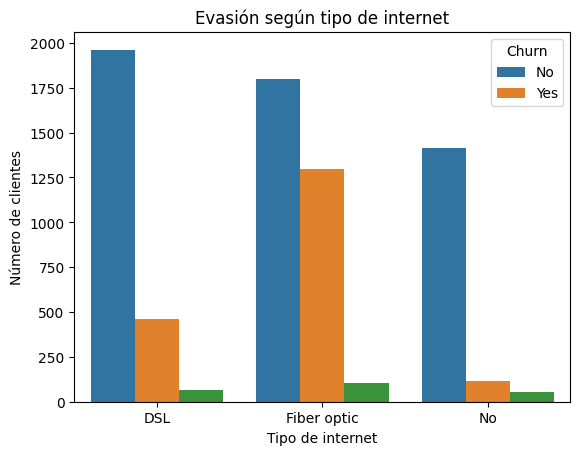

In [34]:
sns.countplot(x='internet_InternetService', hue='Churn', data=df)

plt.title("Evasión según tipo de internet")
plt.xlabel("Tipo de internet")
plt.ylabel("Número de clientes")

plt.show()

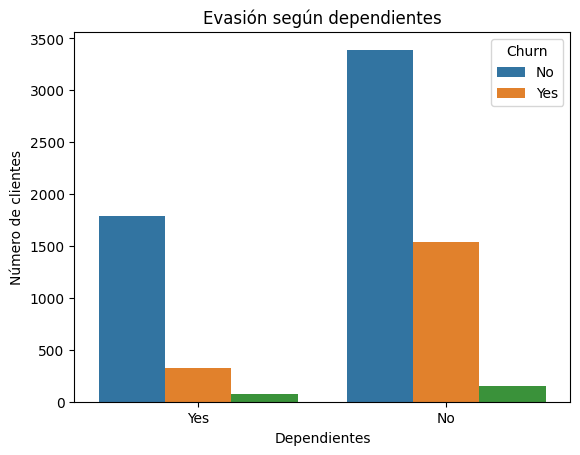

In [35]:
sns.countplot(x='customer_Dependents', hue='Churn', data=df)

plt.title("Evasión según dependientes")
plt.xlabel("Dependientes")
plt.ylabel("Número de clientes")

plt.show()

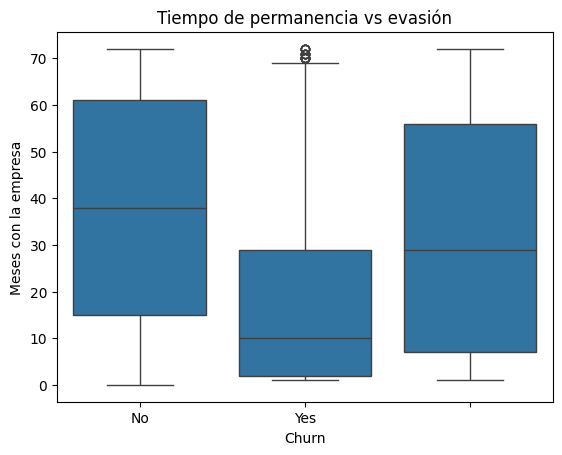

In [36]:
sns.boxplot(x='Churn', y='customer_tenure', data=df)

plt.title("Tiempo de permanencia vs evasión")
plt.xlabel("Churn")
plt.ylabel("Meses con la empresa")

plt.show()

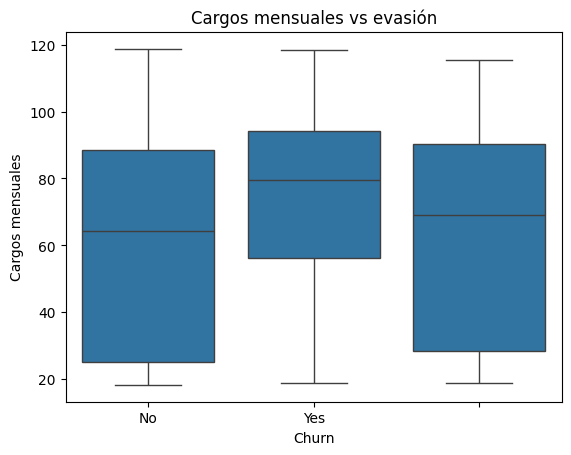

In [37]:
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)

plt.title("Cargos mensuales vs evasión")
plt.xlabel("Churn")
plt.ylabel("Cargos mensuales")

plt.show()

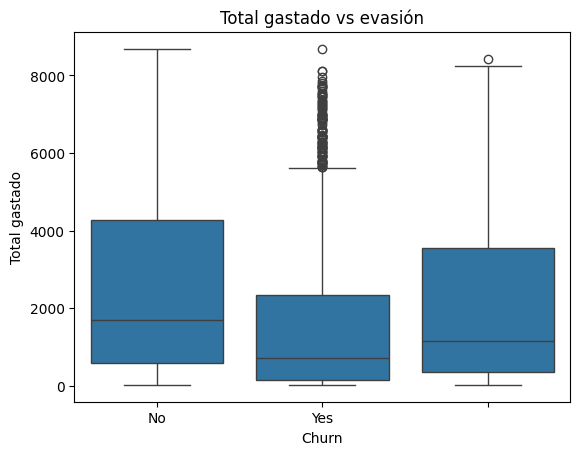

In [38]:
sns.boxplot(x='Churn', y='account_Charges_Total', data=df)

plt.title("Total gastado vs evasión")
plt.xlabel("Churn")
plt.ylabel("Total gastado")

plt.show()

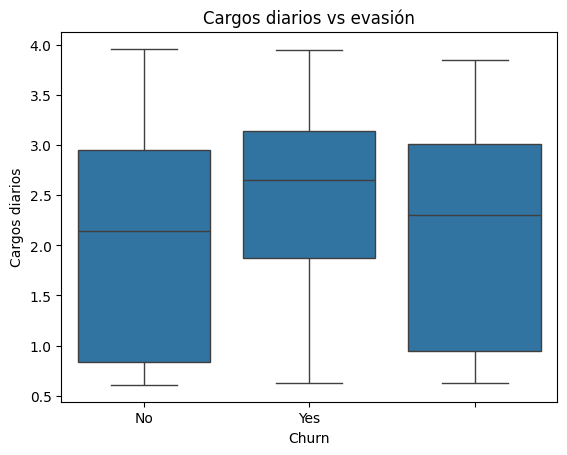

In [39]:
sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df)

plt.title("Cargos diarios vs evasión")
plt.xlabel("Churn")
plt.ylabel("Cargos diarios")

plt.show()

#📄Informe final

**Introducción**

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en Telecom X. La cancelación de servicios representa un problema importante para la empresa, ya que afecta los ingresos y la estabilidad de la base de clientes.
Mediante el uso de Python y bibliotecas de análisis de datos, se analizaron variables demográficas, de servicio y de facturación para identificar patrones asociados al churn.


**Limpieza y Tratamiento de Datos**

Los datos fueron obtenidos desde una API en formato JSON y transformados en un DataFrame de Pandas. Durante el proceso se realizaron las siguientes acciones:

- Normalización de la estructura JSON.

- Verificación de valores nulos y registros duplicados.

- Conversión de variables numéricas.

- Creación de la columna Cuentas_Diarias, calculada a partir de los cargos mensuales.

Esto permitió obtener un conjunto de datos limpio y listo para el análisis.


**Análisis Exploratorio de Datos**

Se realizaron diferentes análisis para entender el comportamiento de los clientes:

- Distribución de la variable Churn para identificar la proporción de clientes que cancelan el servicio.

- Análisis de variables categóricas como género, tipo de contrato y método de pago.

- Análisis de variables numéricas como tiempo de permanencia, cargos mensuales y gasto total.

- Los gráficos permitieron identificar patrones en el comportamiento de los clientes y posibles factores relacionados con la evasión.


**Conclusiones**

El análisis muestra que la evasión de clientes está relacionada con diferentes factores, como el tiempo de permanencia, los cargos del servicio y algunas características del contrato.
Los clientes con menor tiempo en la empresa y ciertos tipos de servicios presentan una mayor probabilidad de cancelar.